In [26]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("ECG5000_balanced.csv")


In [22]:
df

,att1,att2,att3,att4,att5,att6,att7,att8,att9,att10,...,att132,att133,att134,att135,att136,att137,att138,att139,att140,target
0,-0.635587,-1.594733,-1.792081,-2.377737,-2.442025,-2.308995,-2.311829,-2.253411,-2.039034,-1.512639,...,-2.031118,-2.772653,-3.480162,-3.874910,-3.913596,-3.157701,-2.091301,-1.547585,0.149625,2
1,1.203693,1.676928,0.428162,-1.521430,-2.894471,-4.303335,-4.376221,-3.316617,-2.082244,-1.881593,...,0.537608,1.071678,0.937726,1.701423,2.170401,2.363171,1.913464,0.953470,1.550830,1
2,-1.707111,-3.080636,-3.681314,-4.397280,-4.542173,-3.242822,-0.993969,-0.312374,-0.337333,-0.286812,...,0.623562,0.110638,-1.309685,-1.045666,-0.659981,-0.902732,-1.070214,-0.641128,-1.905541,1
3,4.261646,2.268752,-0.135173,-1.615500,-2.635026,-2.517345,-1.344537,-0.501953,-0.466358,0.309286,...,-1.752851,-1.004001,-0.740441,-0.310276,-0.226964,0.173336,0.222312,-0.330147,0.019939,1
4,-1.314147,-3.122485,-4.068301,-4.275174,-3.884163,-3.148948,-1.595125,-0.956926,-0.737890,-0.092787,...,1.402357,1.098818,0.751063,-0.218014,-1.167342,-1.673711,-1.971539,-1.298575,-1.200599,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,-1.824664,-3.396758,-4.008946,-4.217809,-3.737569,-2.708636,-1.821686,-1.562320,-1.055494,-0.645128,...,0.905473,1.026066,1.121236,1.149964,1.108392,1.069803,1.152002,1.189602,0.123324,1
1996,-0.139691,-2.550819,-3.568496,-4.254889,-3.997047,-3.026436,-1.741868,-1.570393,-1.058867,-0.291154,...,1.398897,1.197609,0.950449,0.916011,0.611303,0.534751,0.261311,0.721416,0.536381,1
1997,0.031222,-1.375463,-2.938510,-4.336632,-4.595294,-3.761239,-2.637174,-1.843728,-1.575512,-0.832516,...,1.152863,1.238978,1.619801,1.829909,1.619779,1.237993,1.009506,1.257418,0.384500,1
1998,-0.425499,-2.286119,-3.255744,-3.905569,-3.975967,-3.682565,-2.842319,-1.855444,-1.538784,-1.213368,...,1.122562,1.183245,0.971912,0.550088,0.519355,0.860908,1.164334,0.511642,-1.434612,1


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Columns: 141 entries, att1 to target
dtypes: float64(140), int64(1)
memory usage: 2.2 MB


In [25]:
df.head()

,att1,att2,att3,att4,att5,att6,att7,att8,att9,att10,...,att132,att133,att134,att135,att136,att137,att138,att139,att140,target
0,-0.635587,-1.594733,-1.792081,-2.377737,-2.442025,-2.308995,-2.311829,-2.253411,-2.039034,-1.512639,...,-2.031118,-2.772653,-3.480162,-3.874910,-3.913596,-3.157701,-2.091301,-1.547585,0.149625,2
1,1.203693,1.676928,0.428162,-1.521430,-2.894471,-4.303335,-4.376221,-3.316617,-2.082244,-1.881593,...,0.537608,1.071678,0.937726,1.701423,2.170401,2.363171,1.913464,0.953470,1.550830,1
2,-1.707111,-3.080636,-3.681314,-4.397280,-4.542173,-3.242822,-0.993969,-0.312374,-0.337333,-0.286812,...,0.623562,0.110638,-1.309685,-1.045666,-0.659981,-0.902732,-1.070214,-0.641128,-1.905541,1
3,4.261646,2.268752,-0.135173,-1.615500,-2.635026,-2.517345,-1.344537,-0.501953,-0.466358,0.309286,...,-1.752851,-1.004001,-0.740441,-0.310276,-0.226964,0.173336,0.222312,-0.330147,0.019939,1
4,-1.314147,-3.122485,-4.068301,-4.275174,-3.884163,-3.148948,-1.595125,-0.956926,-0.737890,-0.092787,...,1.402357,1.098818,0.751063,-0.218014,-1.167342,-1.673711,-1.971539,-1.298575,-1.200599,1


In [29]:
print(df.columns.tolist())

['att1', 'att2', 'att3', 'att4', 'att5', 'att6', 'att7', 'att8', 'att9', 'att10', 'att11', 'att12', 'att13', 'att14', 'att15', 'att16', 'att17', 'att18', 'att19', 'att20', 'att21', 'att22', 'att23', 'att24', 'att25', 'att26', 'att27', 'att28', 'att29', 'att30', 'att31', 'att32', 'att33', 'att34', 'att35', 'att36', 'att37', 'att38', 'att39', 'att40', 'att41', 'att42', 'att43', 'att44', 'att45', 'att46', 'att47', 'att48', 'att49', 'att50', 'att51', 'att52', 'att53', 'att54', 'att55', 'att56', 'att57', 'att58', 'att59', 'att60', 'att61', 'att62', 'att63', 'att64', 'att65', 'att66', 'att67', 'att68', 'att69', 'att70', 'att71', 'att72', 'att73', 'att74', 'att75', 'att76', 'att77', 'att78', 'att79', 'att80', 'att81', 'att82', 'att83', 'att84', 'att85', 'att86', 'att87', 'att88', 'att89', 'att90', 'att91', 'att92', 'att93', 'att94', 'att95', 'att96', 'att97', 'att98', 'att99', 'att100', 'att101', 'att102', 'att103', 'att104', 'att105', 'att106', 'att107', 'att108', 'att109', 'att110', 'att111

In [30]:
df['is_anomaly'] = (df['target'] != 1).astype(int)

In [ ]:
X = df.drop(columns=['is_anomaly', 'target'])
y = df['is_anomaly']

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [33]:
model = IsolationForest(n_estimators=100, contamination='auto', random_state=42)
model.fit(X_train)

IsolationForest(random_state=42)

In [34]:
y_pred = model.predict(X_test)

In [35]:
y_pred = np.where(y_pred == -1, 1, 0)

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       534
           1       0.24      0.24      0.24        66

    accuracy                           0.83       600
   macro avg       0.57      0.57      0.57       600
weighted avg       0.83      0.83      0.83       600



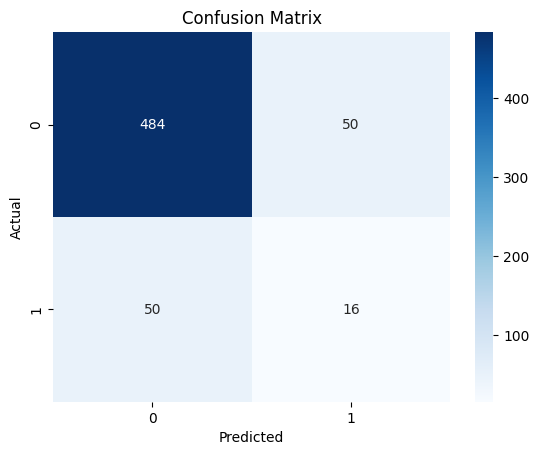

In [36]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [44]:
from sklearn.ensemble import IsolationForest

X = df.drop(columns=['target', 'is_anomaly'])

model = IsolationForest(contamination=0.1, random_state=42)

df['predicted_label'] = model.fit_predict(X)

df['predicted_label'] = df['predicted_label'].map({1: 0, -1: 1})


In [45]:
df['predicted_label'] = df['predicted_label'].apply(lambda x: 0 if x == 1 else 1)

In [46]:
print(df.columns.tolist())

['att1', 'att2', 'att3', 'att4', 'att5', 'att6', 'att7', 'att8', 'att9', 'att10', 'att11', 'att12', 'att13', 'att14', 'att15', 'att16', 'att17', 'att18', 'att19', 'att20', 'att21', 'att22', 'att23', 'att24', 'att25', 'att26', 'att27', 'att28', 'att29', 'att30', 'att31', 'att32', 'att33', 'att34', 'att35', 'att36', 'att37', 'att38', 'att39', 'att40', 'att41', 'att42', 'att43', 'att44', 'att45', 'att46', 'att47', 'att48', 'att49', 'att50', 'att51', 'att52', 'att53', 'att54', 'att55', 'att56', 'att57', 'att58', 'att59', 'att60', 'att61', 'att62', 'att63', 'att64', 'att65', 'att66', 'att67', 'att68', 'att69', 'att70', 'att71', 'att72', 'att73', 'att74', 'att75', 'att76', 'att77', 'att78', 'att79', 'att80', 'att81', 'att82', 'att83', 'att84', 'att85', 'att86', 'att87', 'att88', 'att89', 'att90', 'att91', 'att92', 'att93', 'att94', 'att95', 'att96', 'att97', 'att98', 'att99', 'att100', 'att101', 'att102', 'att103', 'att104', 'att105', 'att106', 'att107', 'att108', 'att109', 'att110', 'att111

In [54]:
X = df.drop(columns=['is_anomaly', 'target'])
y_true = df['is_anomaly']

In [56]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['is_anomaly', 'target'])
y = df['is_anomaly']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model.fit(X_train)
y_pred = model.predict(X_test)


y_pred = [1 if i == -1 else 0 for i in y_pred]


y_true = y_test


In [57]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

Confusion Matrix:
[[500  35]
 [ 46  19]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9158    0.9346    0.9251       535
           1     0.3519    0.2923    0.3193        65

    accuracy                         0.8650       600
   macro avg     0.6338    0.6134    0.6222       600
weighted avg     0.8547    0.8650    0.8594       600



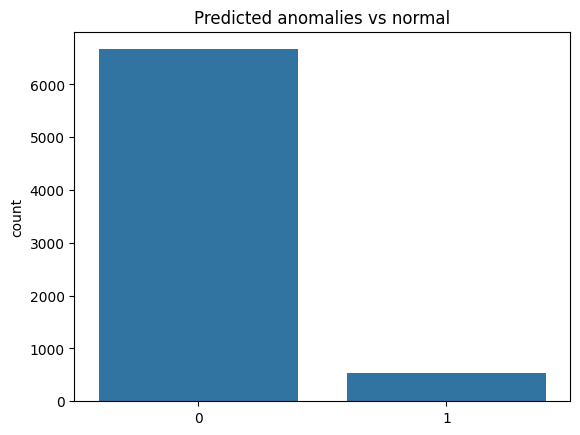

In [84]:
import seaborn as sns
sns.countplot(x=y_pred)
plt.title("Predicted anomalies vs normal")
plt.show()


In [58]:
print(df.columns.tolist())

['att1', 'att2', 'att3', 'att4', 'att5', 'att6', 'att7', 'att8', 'att9', 'att10', 'att11', 'att12', 'att13', 'att14', 'att15', 'att16', 'att17', 'att18', 'att19', 'att20', 'att21', 'att22', 'att23', 'att24', 'att25', 'att26', 'att27', 'att28', 'att29', 'att30', 'att31', 'att32', 'att33', 'att34', 'att35', 'att36', 'att37', 'att38', 'att39', 'att40', 'att41', 'att42', 'att43', 'att44', 'att45', 'att46', 'att47', 'att48', 'att49', 'att50', 'att51', 'att52', 'att53', 'att54', 'att55', 'att56', 'att57', 'att58', 'att59', 'att60', 'att61', 'att62', 'att63', 'att64', 'att65', 'att66', 'att67', 'att68', 'att69', 'att70', 'att71', 'att72', 'att73', 'att74', 'att75', 'att76', 'att77', 'att78', 'att79', 'att80', 'att81', 'att82', 'att83', 'att84', 'att85', 'att86', 'att87', 'att88', 'att89', 'att90', 'att91', 'att92', 'att93', 'att94', 'att95', 'att96', 'att97', 'att98', 'att99', 'att100', 'att101', 'att102', 'att103', 'att104', 'att105', 'att106', 'att107', 'att108', 'att109', 'att110', 'att111

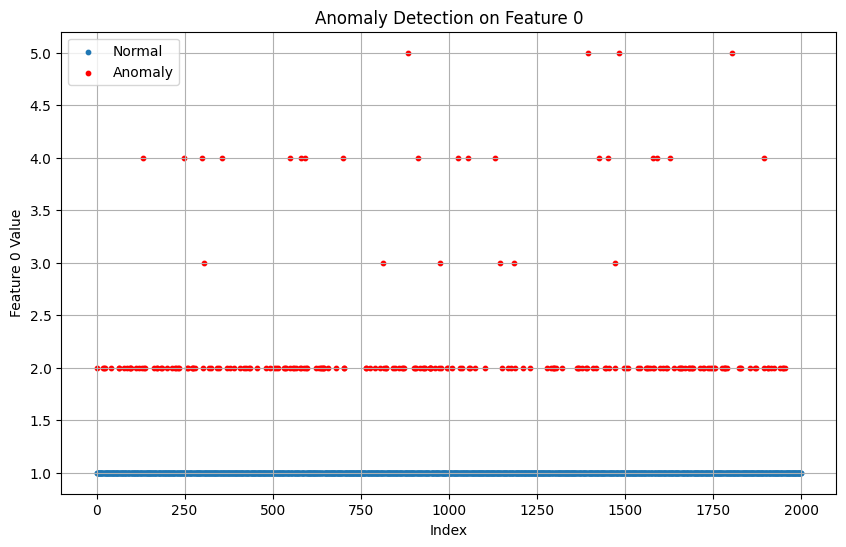

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Normal nuqtalar
plt.scatter(df.index[df['is_anomaly'] == 0], df['target'][df['is_anomaly'] == 0], label="Normal", s=10)

# Anomaliyalar
plt.scatter(df.index[df['is_anomaly'] == 1], df['target'][df['is_anomaly'] == 1], label="Anomaly", s=10, color='red')

plt.legend()
plt.title("Anomaly Detection on Feature 0")
plt.xlabel("Index")
plt.ylabel("Feature 0 Value")
plt.grid(True)
plt.show()




In [66]:
df['anomaly'] = y_pred


anomalies = df[df['anomaly'] == 1]


print("Number of detected anomalies:", anomalies.shape[0])
print(anomalies.head())


Number of detected anomalies: 194
        att1      att2      att3      att4      att5      att6      att7  \
2  -1.707111 -3.080636 -3.681314 -4.397280 -4.542173 -3.242822 -0.993969   
3   4.261646  2.268752 -0.135173 -1.615500 -2.635026 -2.517345 -1.344537   
18 -0.501621 -1.088584 -1.939749 -3.888458 -3.951130 -3.705650 -2.873720   
32  2.856423  0.895378 -1.414143 -2.157897 -2.114629 -1.822889 -0.959043   
41  1.003440  0.772321  0.120992 -0.498031 -0.953221 -1.297942 -1.717449   

        att8      att9     att10  ...    att135    att136    att137    att138  \
2  -0.312374 -0.337333 -0.286812  ... -1.045666 -0.659981 -0.902732 -1.070214   
3  -0.501953 -0.466358  0.309286  ... -0.310276 -0.226964  0.173336  0.222312   
18 -1.951708 -1.150802 -0.888869  ...  1.505033  1.765617  2.033467  2.039252   
32  0.194627  0.353224  0.642431  ... -0.612182 -0.978294 -0.863900 -0.465926   
41 -1.811079 -1.555743 -1.095497  ... -3.149124 -3.525368 -4.080990 -4.156829   

      att139    att140

In [67]:
anomalies.to_csv('topilgan_anomalies.csv', index=False)
print("Anomaly cases saved to topilgan_anomalies.csv")


Anomaly cases saved to topilgan_anomalies.csv


In [69]:
df['Anomaly_Label'] = df['is_anomaly'].map({0: 'Normal', 1: 'Anomaly'})


print(df[['target', 'Anomaly_Label']].head(200))



     target Anomaly_Label
0         2       Anomaly
1         1        Normal
2         1        Normal
3         1        Normal
4         1        Normal
..      ...           ...
195       1        Normal
196       1        Normal
197       1        Normal
198       1        Normal
199       1        Normal

[200 rows x 2 columns]
